# Top-Level Aircraft Requirements

In [1]:
# List of top-level aircraft requirements for the EADG aircraft
# All units are in SI unless stated explicitly

aircraft_range= 190 * 10**3          # [m] electric mission point from the paper #155.8 for a 18 percent range reduction to make it feasible
hybrid_range = 340 * 10**3           # [m] hybrid mission point from the paper
payload=1805                         # [kg]
cruise_speed= 82.311                  # [m/s]
pax=19
max_speed=82.311 # m/s
MTOM=8600 # Kilogram                # Target MTOM
ceiling_alt=25000 * 0.3048          # [m]
cruise_alt=10000 * 0.3048           # [m]
tofl=1440                           # [m]
IFR_reserves=185 * 10**3 #meters    # 100 nm reserve 
IFR_reserve_time=45*60 #seconds     # 45 minute endurance 
loiter_time = IFR_reserve_time 
loiter_distance=cruise_speed* loiter_time # seconds
loiter_alt= 10000 * 0.3048          # [m]
loiter_speed=0.80*max_speed           # m/s
takeoff_speed= 41.15     # m/s
climb_speed= 1.52        # m/s
landing_distance=1200                 # [m]
#rate_of_climb = 300 * 0.00508         # [m/s]
loiter_range= 20000 
approach_speed = 109 * 0.514444       # [m/s]
MTOM_limit=8618 #kg                   # Target MTOM [kg]
g=9.81
climb_speed = 300 * 0.3048            # [m/s]
climb_range=20000                     # [m]
descent_range= 5000                   # [m]
rho_loiter_alt=  0.9046               #[kg/m3]
rho_cruise=  0.9046               #[kg/m3]
psfc_kg_per_kwh=0.34              #GTE PSFC [KWh]


# Plot Mission 

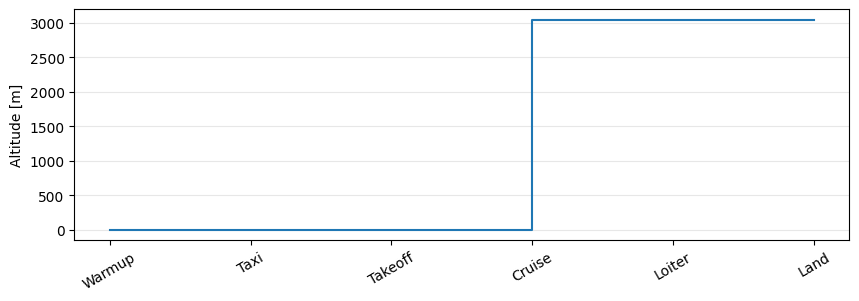

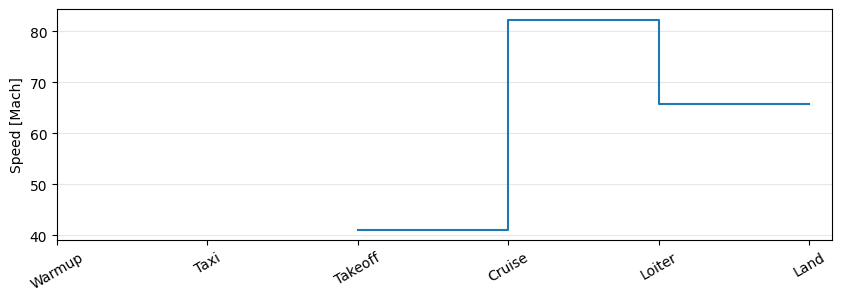

In [2]:
from mission_utils import validate_mission, plot_mission_altitude, plot_mission_speed

########################################Mission Dictionary################################################################################
#Initial definition of the mission - mainly for the plot below,
#For the E19 aircraft warmup, taxi, takeoff are neglected and replaced by adding an equivalent energy value to the battery sizing equation
#Climb is not modelled in the sizing loop at all
#L/D values are place holders and will be updated further into the notebook
###########################################################################################################################################

mission = [
    {"phase": "warmup"},
    {"phase": "taxi"},

    {"phase": "takeoff",
     "tofl": tofl,
     "max_speed": takeoff_speed,
    },

    {"phase": "cruise",
     "range": aircraft_range,   # [m]
     "cruise_speed": cruise_speed,
     "cruise_alt": cruise_alt,
     "payload": payload,
     "pax": pax,
     "MTOM": MTOM_limit,
     "l_d": 15.0,               # [-] dummy L/D during cruise - THESE ARE UPPDATED LATER!
    },

    {"phase": "loiter",
     "loiter_time": loiter_time,  # [s]
     "loiter_speed": loiter_speed,
     "loiter_alt": loiter_alt,
     "range": loiter_range,                # [m] dummy "equivalent range" for loiter - THESE ARE UPPDATED LATER!
     "l_d": 14.0,                      # [-] dummy L/D during loiter - THESE ARE UPPDATED LATER!
     "MTOM": MTOM_limit,
    },

    {"phase": "land"}
]

mission = validate_mission(mission)

plot_mission_altitude(mission)
plot_mission_speed(mission)

# Specify Aircraft Configuration 

In [3]:
####################Aircraft Configuration Parameters#############################
# Define aircraft configuration here 
##################################################################################

A= 12 # aspect ratio
lam= 0.39 # Taper ratio
c_root= 2.27 # root chord length in meters
c_tip= c_root*lam # #tip chord in meters
swet_sref= 4.5 # assumption 1.75
#CL=0.5 # Assumption
sweep_c_4=0
sweep_c_2=0
wing_type="low"
t_c_root= 0.12 # assumed root thickness to chord ratio for turboprops

# Estimate/Specify Aerodynamic Coefficients using Class 1 Methods 

In [4]:
#######################Class 1 Aero###############################
#Imports class 1 aero and esitamtes LDmax and CLmax for key phases based on inputs from the aircraft configuration cell

import importlib
import class_1_aero

importlib.reload(class_1_aero)


LDmax = class_1_aero.ld_max_lofi(
    aircraft_type="prop_retractable",
    AR=A,
    swet_sref=swet_sref
)

print(f"(L/D)_max = {LDmax:.2f}")

# CD = class_1_aero.drag_polar_lofi(
#     aircraft_type="large_turboprop",
#     CL=CL,
#     AR=A
# )

#print(f"CD = {CD:.4f}")

CL_max_clean, CL_max_TO, CL_max_landing = class_1_aero.CL_max(    #CLmax TO needs to be set to 2.580 to get the E19 W/P design point in the feasible reagion)
    "small_twin_engine_props",
    fid_range="hi"
) 
#################################### Note ########################################
# Although the aerodynamic coefficients are being computed here 
# In order to repicate the E-19 mission the L/D max needs to be set to 19
# in the energy calculation and the Cl_max_TO needs to be set to 2.580 to get the 
# E-19 W/P in the feasible reagion of the constraint plot
#################################### Note ########################################
print(f"CL_max_clean = {CL_max_clean:.2f}")
print(f"CL_max_TO = {CL_max_TO:.2f}")
print(f"CL_max_landing = {CL_max_landing:.2f}")



(L/D)_max = 17.96
CL_max_clean = 1.80
CL_max_TO = 2.00
CL_max_landing = 2.50


In [5]:
# See Table 3.6 for delta CD inputs

CD_clean= class_1_aero.drag_polar_lofi(
    aircraft_type="large_turboprop",
    CL=CL_max_clean,
    AR=A,
    delta_cd0_flaps=0,
    delta_cd0_lg=0,
    delta_e_flaps=0
)

CD_TO= class_1_aero.drag_polar_lofi(
    aircraft_type="large_turboprop",
    CL=CL_max_TO,
    AR=A,
    delta_cd0_flaps=0.020, # conservative values from table 3.6, Roskam Vol-1, page 127
    delta_cd0_lg=0.025,
    delta_e_flaps=0.05
    
)

CD_LND= class_1_aero.drag_polar_lofi(
    aircraft_type="large_turboprop",
    CL=CL_max_TO,
    AR=A,
    delta_cd0_flaps=0.075, # conservative values from table 3.6, Roskam Vol-1, page 127
    delta_cd0_lg=0.025,
    delta_e_flaps=-0.05
    
)

L_D_TO=CL_max_TO/CD_TO
L_D_LND=CL_max_landing/CD_LND

print(f"CD_clean = {CD_clean:.2f}")
print(f"CD_TO = {CD_TO:.2f}")
print(f"CD_LND = {CD_LND:.2f}")
print(f"L_D_TO = {L_D_TO:.2f}")
print(f"L_D_LND = {L_D_LND:.2f}")


CD_clean = 0.12
CD_TO = 0.18
CD_LND = 0.25
L_D_TO = 11.06
L_D_LND = 9.97


# Prepare Inputs to Constraint Analysis

In [35]:
constraint_analysis_inputs = {
    "density": 1.225, #kg/m3
    "stall_speed": 43.1, #m/s
    "Quarter chord sweep": sweep_c_4,
    "landing_distance": landing_distance,
    "rho_ratio": 1.0,
    "aircraft_type": "Twin turboprop",
    "propulsion_type": "prop",           
    "cruise_speed": cruise_speed,
    "AR": A,
    "CD_0": 0.020, #Mid value table 6 -tuboprop
    "CL_max_to": CL_max_TO,#2.580,#,CL_max_TO, #2.5800 brings the E-19 design point into the feasible reagion 
    "CL_max": CL_max_clean,
    "CL_max_L": CL_max_landing,
    "climb_gradient": 0.06,
    "rate_of_climb": climb_speed,
    "rho_ceiling": 0.5489,
    "rho_cruise": rho_cruise,
    "rho_climb": 1.1,
    "rho_loiter_alt": rho_loiter_alt,
    "oswald efficiency": 0.8,
    "cl_max_foil": None,
    "propeller_efficiency": 0.8,
    "eta_total": 0.24 * 0.83 *0.80 #thermal efficiency of gte * gearbox efficiency * propeller efficiency
}

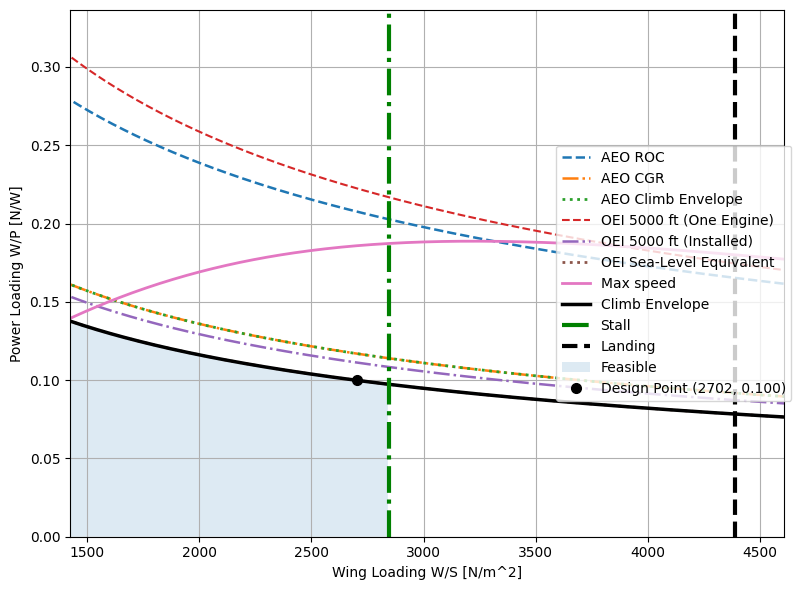

{'feasible': True, 'WS_star': 2702.2420468749997, 'WP_star': np.float64(0.09989438196728961)}


In [36]:
import importlib
import SMP
import SMP_W_P

# importlib.reload(SMP)

# constraint_results = SMP.constraints_raymer(constraint_analysis_inputs)

# plot_results = SMP.plot_constraint_diagram(constraint_results, constraint_analysis_inputs)

# print(plot_results)



importlib.reload(SMP_W_P)

constraint_results_wp = SMP_W_P.constraints_raymer(constraint_analysis_inputs)
plot_results_wp = SMP_W_P.plot_constraint_diagram(
    constraint_results_wp,
    constraint_analysis_inputs,
    include_ceiling_constraint=False,
    include_loiter_constraint=False,
    margin_factor=0.95,
)
print(plot_results_wp)


In [8]:
################## Note on design point selection######################################
# The design point for the E-19 aircraft is a W/S of 2546 W/m2 and a W/P of 0.0676 W/N#
# If I remove the ceiling and loiter constraints then this design point falls into the#
# feasible region. This design point gives a class 2 MTOM of close to 9000 kg, driven#
# mainy by a high propulsion system mass. If I chose the design point instead, the   # 
# class II mass estimate drops to 8778 kg instead.                                    #  
################## Note on design point selection######################################

w_p_sel=0.0676 #N/W Selected power loading - Based on E19 
w_s_sel=2546 #N/m2 Seected wing loading - Based on E-19

p_w_sel= 1/ w_p_sel                #W/N - Invert to get P/W to make downstream calculations easier
w_s_sel_kg_m2=w_s_sel/9.81         #kg/m2  Convert to kg/m2 since class 2 airframe sizing takes it in kg/m2

S_wing=(MTOM_limit)/w_s_sel_kg_m2   #Estimate wing area in meters2
P_rated= p_w_sel*MTOM_limit*9.81    #Estimate rated power in Watts

################Print Block#################
print("Wing area in m2 is",S_wing)
print("Total power in Watts is", P_rated)\
################Print Block#################




Wing area in m2 is 33.206040848389634
Total power in Watts is 1250629.881656805


# Powertrain specifcaiton and sizing

In [9]:
import powertrain_component_sizing
import special_functions

########Specify component efficiencies###########
eta_1=0.24
eta_2=0.95
eta_3=0.80
e_bat= 160 * 3600                  # J/kg
e_f=42.8e6 # J/kg
k_bat=1.18
eta_te=eta_1                       #thermal engine efficiency
eta_m=0.95                         #electric motor transmission efficiency
eta_gb=0.99                        #gearbox efficiency
eta_p=0.8                          #propeller efficiency
Phi=1                              # set hybridization factor for power train sizing
eta_total=eta_te*eta_gb*eta_p
########Specify component efficiencies###########

if Phi == 1: #All electric case
    cruise_power_loading_dict= special_functions.estimate_propeller_cruise_power_loading(loiter_speed,eta_p,LDmax,w_s_sel,rho_loiter_alt,constraint_analysis_inputs["CD_0"],A,constraint_analysis_inputs["oswald efficiency"])
    W_P_cruise=cruise_power_loading_dict["W_P_cruise"]   #Here the assumption is that the therma engine is sized only for cruise so this computes the required W/P at the design wing loading
    #print(W_P_cruise)
    
    
    therm_W_P_Watts=powertrain_component_sizing.WP_therm_eng_parallel_alt(w_p_sel, Phi, eta_p, eta_gb, eta_te, eta_m)    #Estimate thermal engine W/P
    EM_W_P_Watts=powertrain_component_sizing.WP_em_parallel(w_p_sel, Phi, eta_p, eta_gb, eta_te, eta_m)                  #Estimate electric motor W/P
    #Batt=WP_batt_parallel(w_p_sel, Phi, eta_p, eta_gb, eta_te, eta_em)
    WP_batt=powertrain_component_sizing.WP_batt_parallel(w_p_sel, Phi, eta_p, eta_gb, eta_te, eta_m)                     #Estimate battery W/P

    W_P_EM=EM_W_P_Watts                 # Storing for use in later calculations
    W_P_TE=W_P_cruise#W_P_cruise #therm_W_P_Watts#W_P_cruise   # Storing for use in later calculations
   
    ################Print Block#################
    print("Electric motor W/P",EM_W_P_Watts)
    print("Thermal engine W_P",W_P_TE)
    print("WP_batt is:",WP_batt)
    ################Print Block#################
else:
    EM_W_P_Watts=powertrain_component_sizing.WP_em_parallel(w_p_sel, Phi, eta_p, eta_gb, eta_te, eta_m)                    #Estimate thermal engine W/P
    W_P_te=powertrain_component_sizing.WP_therm_eng_parallel_alt(w_p_sel, Phi, eta_p, eta_gb, eta_te, eta_m)               #Estimate electric motor W/P
    cruise_power_loading_dict= special_functions.estimate_propeller_cruise_power_loading(loiter_speed,eta_p,LDmax,w_s_sel,rho_loiter_alt,constraint_analysis_inputs["CD_0"],A,constraint_analysis_inputs["oswald efficiency"])            #Cruise power loading at selected W/S point 
    #W_P_te=cruise_power_loading_dict["W_P_cruise"]
    W_P_EM=EM_W_P_Watts
    W_P_TE=W_P_te
    WP_batt=(w_p_sel, Phi, eta_p, eta_gb, eta_te, eta_m)

    ################Print Block#################
    print(EM_W_P_Watts)
    print(W_P_te)
    print(WP_batt)
    ################Print Block#################

Electric motor W/P 0.08535353535353535
Thermal engine W_P 0.20785229009507492
WP_batt is: 0.08984582668793195


# Update Mission Dictionary To Prepare it for Class I Sizing 

In [10]:
# Note: For the E19 all electric misison only the cruise phase and the ifr phase matter. Energy allowances are factored into battery sizing for all the other phases except climb. Cimb isnt modelled at all for some reason 


mission = [
    {"phase": "warmup"},
    {"phase": "taxi"},

    {"phase": "takeoff",
     "tofl": tofl,
     "max_speed": takeoff_speed,
    },


    {"phase": "cruise",
     "range": aircraft_range,   # [m]
     "cruise_speed": cruise_speed,
     "cruise_alt": cruise_alt,
     "payload": payload,
     "pax": pax,
     "MTOM": MTOM_limit,        # Initial guess MTOM
     "l_d": 19.3,               # [-] This is used to match L/D specified in the E-19 paper  
     "Phi": 1,
     
    },

     {"phase": "ifr",
     "target_altitude": loiter_alt,
     "range": IFR_reserves,     # [m] 
     "l_d": 19.3,               # [-] This is used to match L/D specified in the E-19 paper  
     "MTOM": MTOM_limit,
     "Phi": 1,
      "loiter_speed":0.60*cruise_speed
    },

    #removed descent since its covered in the allowances

    {"phase": "land"},
]

# Perform Class I Sizing 

In [15]:
#mission = inputs["mission"]
import special_functions
import class_1_sizing
importlib.reload(special_functions)
importlib.reload(class_1_sizing)

mtom_guess = MTOM

g        = 9.81
tol      = 1
max_iter = 100
relax    = 1.0
oe_args  = (1,1)
l_d_cruise = float(next(ph["l_d"] for ph in mission if ph["phase"] == "cruise"))
phi= float(next(ph["Phi"] for ph in mission if ph["phase"] == "cruise"))
energy_allowances=233.28e+06 #Joules - allowances for warmup, taxi, takeoff and descent from https://elib.dlr.de/132771/1/eCommuter.pdf

aircraft_range_in=aircraft_range




err = 1e9
i = 0
history = []

while err > tol and i < max_iter:
    OE = class_1_sizing.oe_mass(payload, mtom_guess, *oe_args)
    
    cruise_frac=special_functions.conventional_breguet_weight_fraction( IFR_reserves,l_d_cruise,eta_total,e_f,g)
    endurance_frac=special_functions.conventional_breguet_loiter_weight_fraction_psfc(loiter_time,loiter_speed,l_d_cruise,eta_p,psfc_kg_per_kwh,g)
    f_range = cruise_frac["fuel_fraction"]
    f_loiter = endurance_frac["fuel_fraction"]
    f_total = 1.0 - (1.0 - f_range) * (1.0 - f_loiter)
    fuel_mass_kg = f_total * mtom_guess*1.05 #total fuel mass including 5% trapped fuel

    if phi < 1:
        E0_total=class_1_sizing.compute_E0_tot_hybrid_single_phase(aircraft_range_in, OE*g, payload*g, l_d_cruise, eta_1,eta_2, eta_3,phi, e_bat,e_f, g)
        E0_fuel=(1-phi)*E0_total
        E0_bat=phi*E0_total
        W_f=E0_fuel/e_f
        W_bat=E0_bat/e_bat
        fuel_mass_kg +=W_f # comment out for electric case
        #fuel_mass_kg =W_f #uncomment for hybrid case
    else:
        E0_total=class_1_sizing.compute_E0_tot_electric_single_phase(aircraft_range_in, OE*g, payload*g, l_d_cruise, eta_2, eta_3, e_bat, g)
    

    # E0_total, phase_results = mission_E0_bat_by_phase_electric(
    #     mission=mission,
    #     W_OE=OE,
    #     W_PL=payload,
    #     eta_2=eta_2,
    #     eta_3=eta_3,
    #     e_bat_J_per_kg=e_bat,
    #     g=g
    # )
    if phi <1:
        M_batt = class_1_sizing.battery_pack_mass(E0_bat + energy_allowances, e_bat, k_bat)
    else:
        
        M_batt = class_1_sizing.battery_pack_mass(E0_total + energy_allowances, e_bat, k_bat)

    mtom_new_raw = OE + M_batt + payload+fuel_mass_kg
    mtom_new = relax * mtom_new_raw + (1 - relax) * mtom_guess

    err = abs(mtom_new - mtom_guess)

    history.append({
        "iter": i + 1,
        "MTOM_guess": mtom_guess,
        "OE": OE,
        "E0_total_J": E0_total,
        "M_batt": M_batt,
        "MTOM_new": mtom_new,
        "error": err
    })

    mtom_guess = mtom_new
    i += 1

MTOM_class_1=mtom_guess
class1_tables = special_functions.display_class1_convergence_tables(
    mtom_kg=mtom_guess,
    oe_kg=OE,
    battery_mass_kg=M_batt,
    e0_total_j=E0_total,
    fuel_mass_kg=fuel_mass_kg,
    iterations=i,
    error_kg=err,
    history=history,
    e0_fuel_j=E0_fuel if phi < 1 else None,
)


,Parameter,Value,Units,Notes
0,MTOM,9.241258e+03,kg,Final converged Class I MTOM
1,OE,4.604315e+03,kg,Final converged operating empty mass
2,Battery mass,2.618666e+03,kg,Final converged battery mass
3,Mission E0 total,1.044984e+09,J,Final onboard mission energy
4,Mission E0 total,1.044984e+03,MJ,Final onboard mission energy
5,Fuel mass,2.132769e+02,kg,Total fuel mass
6,Iterations,6.000000e+00,-,Number of iterations
7,Final error,9.326799e-01,kg,Final MTOM residual


,Iter,MTOM guess [kg],OE [kg],E0_total [J],Battery [kg],MTOM new [kg],Error [kg]
0,1,8600.000000,4476.250000,1.024104e+09,2575.891002,9055.638459,455.638459
1,2,9055.638459,4567.377692,1.038962e+09,2606.328427,9187.720213,132.081754
2,3,9187.720213,4593.794043,1.043269e+09,2615.151713,9226.008442,38.288229
3,4,9226.008442,4601.451688,1.044517e+09,2617.709432,9237.107541,11.099099
4,5,9237.107541,4603.671508,1.044879e+09,2618.450871,9240.324979,3.217438
5,6,9240.324979,4604.314996,1.044984e+09,2618.665801,9241.257659,0.932680


In [16]:
import class_2_airframe_structure
import math
b_wing=math.sqrt(A * S_wing)
tail_inputs = {
    "MTOM_kg": MTOM_class_1,
    "S_w_m2": S_wing,
    "b_w_m": b_wing,
    "c_bar_w_m": (c_root+c_tip)/2,   # mean wing chord
    "c_ht": 0.90,               # example value
    "c_vt": 0.08,              # example value
    "a_fus": 0.169,
    "c_fus": 0.51,
    "ht_arm_fraction": 0.52,   # example for wing-mounted engines
    "vt_arm_fraction": 0.52,   # can use same first estimate
}

tail_out = class_2_airframe_structure.tail_areas_from_volume_coefficients(**tail_inputs)
print("Fuselage length [m]:", tail_out["l_f_m"])
print("Horizontal tail arm [m]:", tail_out["L_ht_m"])
print("Vertical tail arm [m]:", tail_out["L_vt_m"])
print("Horizontal tail area [m^2]:", tail_out["S_ht_m2"])
print("Vertical tail area [m^2]:", tail_out["S_vt_m2"])
l_f_m= tail_out["l_f_m"]
L_ht_m= tail_out["L_ht_m"]
L_vt_m= tail_out["L_vt_m"]
S_ht_m2= tail_out["S_ht_m2"]
S_vt_m2= tail_out["S_vt_m2"]


Fuselage length [m]: 17.79957181022966
Horizontal tail arm [m]: 9.255777341319424
Vertical tail arm [m]: 9.255777341319424
Horizontal tail area [m^2]: 5.093981582674351
Vertical tail area [m^2]: 5.729191753502975


In [17]:
import class_2_airframe_structure
import systems_simplified
importlib.reload(systems_simplified)

mission = mission
payload = payload
eta_1 = eta_1
eta_2 = eta_2
eta_3 = eta_3
e_bat = e_bat
e_f = e_f
k_bat = k_bat
mtom_guess = MTOM_class_1
g = 9.81
tol = 1.0
max_iter = 100
relax = 1.0
n_pax=19
n_crew=2
a_speed_sound=340.3   #[m/s]
max_mach=max_speed/a_speed_sound
engine_diameter=0.53 #[m] - based on https://en.wikipedia.org/wiki/Honeywell_TPE331 - used on the DO-228

# ##########################################################################
# Powertrain Inputs
# ##########################################################################

eta_p = 0.8 # propeller efficiency 
eta_total = eta_total # GTE, GB, Propeler power train efficiency
psfc_kg_per_kwh = psfc_kg_per_kwh #power specific fuel consumption in [kWh]
energy_allowances = 233.28e6 # Additional energy allowances to account for taxi, take-off , descent, landing and warmup per DLR paper

# ##########################################################################
# Class 2 Wing Sizing Inputs
# ##########################################################################

w_s_sel = w_s_sel_kg_m2 #selected wing loading
A = A                #Aspect ratio
lam = lam            #Taper Ratio
t_c_root = t_c_root  #thickness to chord ratio
sweep_half_chord_deg = sweep_c_2 #Half chord sweep in degrees
n_ult = 5.7                      #utilization factor
category = "light"               #aircraft category    
engines_wing_mounted = 2         #wing mounted engines
main_gear_attached_to_wing = False
b_ref_m = 1.905                  #reference span - assumed

# ##########################################################################
# Tail Sizing Inputs
# ##########################################################################

k_wt = 0.64
c_ht = 0.90                     #HT tail volume coefficient
c_vt = 0.08                     #VT tail volume coefficient
a_fus = 0.169                   #Emperical coefficent for turboprops from Raymer
c_fus = 0.51                    #Emperical coefficent for turboprops from Raymer
ht_arm_fraction = 0.52
vt_arm_fraction = 0.52

# ##########################################################################
# Fuselage sizing inputs
# ##########################################################################
l_f_m = l_f_m                 #Length of fuselage in meters
V_D_mps = 144.0               #Dive speed in meters per second - assumed
l_t_m = L_ht_m  #7.5          # 𝑙𝑡 is the tail arm between the 25% chord location
                              #of the root chord of the main wing and the horizontal tail, measured in top-view on the fuselage centerline
b_f_m = 2.2                   #Fuselage width 
h_f_m = 2.4                   #Fuselage height
S_G_m2 = 95.0                 #Fuselage gross shell area in m2
k_wf = 0.23
pressurized = True
fuselage_mounted_engines = False
main_gear_attached_to_fuselage = True
freighter = False
no_attachment_structure_or_gear_bay = False

# ##########################################################################
# Landing Gear Sizing Inputs
# ##########################################################################

wing = "low"
retractable = True

# ##########################################################################
# Nacelle and Pylon Inputs
# ##########################################################################

ESHP_to_hp = 1600.0
gear_retracts_into_nacelle = False
over_wing_exhaust = False
nacelle_type = "prop"

# ##########################################################################
# Reserve / Mission Fuel Inputs
# ##########################################################################

IFR_reserves = IFR_reserves
loiter_time = loiter_time
loiter_speed = loiter_speed


# ##########################################################################
# Control Surface Areas Estimated as a Fraction of HT and VT areas
# ##########################################################################

s_total_ailerons= 2 * 1.345 #[m2] - based on DO-228 data https://dh0f9za0kua5m.cloudfront.net/uploads/2019/07/Fixed-wing-Dornier-228.pdf
s_total_rudder= 1.5 #[m2]
s_total_elevator = 0.30 * 8.33 #[m2] assumed as 30% of tail area



In [18]:

import class_2_systems as c2sys

m_hydraulic_kg = c2sys.hydraulic_system_weight_kg(fuselage_length_m=l_f_m, fuselage_width_m=b_f_m, wing_area_m2=S_wing, v_max_mach=max_mach, n_wing_engines=engines_wing_mounted, n_fuselage_engines=0)
print("mass of hydraulic systems is",m_hydraulic_kg)
m_avionics_kg = c2sys.avionics_system_weight_kg(design_range_m=aircraft_range_in, n_flight_crew=n_crew, fuselage_length_m=l_f_m, fuselage_width_m=b_f_m)
print("mass of avionics systems is",m_avionics_kg)
m_ecs_kg = c2sys.air_conditioning_system_weight_kg(fuselage_length_m=l_f_m, fuselage_width_m=b_f_m, fuselage_depth_m=h_f_m, n_passengers=n_pax, v_max_mach=max_mach, avionics_weight_kg=m_avionics_kg)
print("mass of ECS is",m_ecs_kg)

m_electrical_kg = c2sys.electrical_system_weight_kg(fuselage_length_m=l_f_m, fuselage_width_m=b_f_m, n_engines=engines_wing_mounted, n_passengers=n_pax, n_flight_crew=n_crew)
print("mass of electrical systems is", m_electrical_kg)

m_furnishings_mohan_kg = c2sys.galley_entertainment_furnishing_weight_mohan_kg(n_crew=n_crew, n_passengers=n_pax, cabin_volume_m3=0.7*l_f_m*b_f_m*h_f_m)
print("mass of Mohan galley and furnishings is", m_furnishings_mohan_kg)


m_ips_kg = c2sys.ice_protection_system_weight_kg(wing_span_m=b_wing, wing_sweep_quarter_chord_deg=sweep_c_4, n_engines=engines_wing_mounted, engine_diameter_m=engine_diameter, fuselage_width_m=b_f_m)
print("mass of ice protection systems is", m_ips_kg)

m_instruments_kg = c2sys.instruments_system_weight_kg(fuselage_length_m=l_f_m, fuselage_width_m=b_f_m, v_max_mach=max_mach, n_flight_crew=n_crew, n_wing_engines=engines_wing_mounted, n_fuselage_engines=0)
print("mass of instruments systems is", m_instruments_kg)

m_mech_fcs=systems_simplified.mechanical_fcs_weight(s_total_ailerons, s_total_rudder, s_total_elevator)

print("Mechaical FCS mass is ",m_mech_fcs)


total_systems_mass= m_hydraulic_kg/2  + m_avionics_kg/2 + m_ecs_kg+m_electrical_kg/2+m_ips_kg+m_instruments_kg 

furnishings_kg= m_furnishings_mohan_kg
operator_items_kg=180

print("Total systems mass is :",total_systems_mass)




mass of hydraulic systems is 88.87326363005225
mass of avionics systems is 248.78264443214144
mass of ECS is 75.53149531248263
mass of electrical systems is 504.38006093172754
mass of Mohan galley and furnishings is 572.2792916741369
mass of ice protection systems is 40.61166026520828
mass of instruments systems is 57.05466775773076
Mechaical FCS mass is  53.656162143679154
Total systems mass is : 594.2158078323822


In [19]:
import systems_simplified 
importlib.reload(systems_simplified)


sys_weight_breakdown=systems_simplified.compute_systems_electrical_power_E19(l_f_m,S_wing,0.7*l_f_m*b_f_m*h_f_m,2,aircraft_range_in,cruise_speed)
total_energy=sys_weight_breakdown["total_energy_j"]
p_lights=sys_weight_breakdown["p_lights_kw"]
p_avionics_kw=sys_weight_breakdown["p_avionics_kw"]
p_fuel_system_kw=sys_weight_breakdown["p_fuel_system_kw"]

print("total energy is:",total_energy)
print("p_lights is :",p_lights)
print("p_avionics_kw is:",p_avionics_kw)
print("p_fuel_system_kw is:",p_fuel_system_kw)



total energy is: 26222835.444656994
p_lights is : 5.517867261171195
p_avionics_kw is: 1.7344620657200245
p_fuel_system_kw is: 4.10781703250437


In [20]:
def converge_mtom_with_class2_struct_oe(
    mission,
    n_pax,
    n_crew,
    payload,
    a_speed_sound,
    max_speed,
    rho_cruise,
    eta_1,
    eta_2,
    eta_3,
    e_bat,
    e_f,
    k_bat,
    mtom_guess,
    g,
    tol,
    max_iter,
    relax,
    w_s_sel,
    A,
    lam,
    t_c_root,
    sweep_half_chord_deg,
    n_ult,
    category,
    engines_wing_mounted,
    main_gear_attached_to_wing,
    b_ref_m,
    k_wt,
    c_ht,
    c_vt,
    a_fus,
    c_fus,
    l_f_m,
    ht_arm_fraction,
    vt_arm_fraction,
    V_D_mps,
    l_t_m,
    b_f_m,
    h_f_m,
    S_G_m2,
    k_wf,
    s_total_ailerons,
    s_total_rudder,
    s_total_elevator,
    engine_diameter,
    pressurized,
    fuselage_mounted_engines,
    main_gear_attached_to_fuselage,
    freighter,
    no_attachment_structure_or_gear_bay,
    wing,
    retractable,
    nacelle_type,
    ESHP_to_hp,
    gear_retracts_into_nacelle,
    over_wing_exhaust,
    T_to_N,
    k_n,
    thrust_reverser,
    IFR_reserves,
    loiter_time,
    loiter_speed,
    eta_total,
    eta_p,
    psfc_kg_per_kwh,
    W_P_EM,
    W_P_TE,
    W_P_batt,
    P_W_sel,
    energy_allowances=233.28e6,
    reserve_fuel_mode="add",
    
):
    import math
    import class_1_sizing
    import class_2_airframe_structure as c2
    import special_functions
    import class_2_prop_parallel_hybrid
    import class_2_battery_sizing
    import class_2_systems as c2sys
    import systems_simplified as ss

    max_mach=max_speed/a_speed_sound
    cruise_phase = next(ph for ph in mission if str(ph["phase"]).lower() == "cruise")
    l_d_cruise = float(cruise_phase["l_d"])
    phi = float(cruise_phase.get("Phi", 1.0))
    aircraft_range = float(cruise_phase["range"])
    

    err = 1e9
    i = 0
    history = []

    last_breakdown = None
    last_tail_out = None
    last_geometry = None
    fuel_mass_kg = 0.0
    E0_total = 0.0
    M_batt = 0.0
    OE = 0.0

    while err > tol and i < max_iter:
        # ------------------------------------------------------------------
        # Geometry update from current MTOM guess
        # ------------------------------------------------------------------
        W_G_kg = mtom_guess
        W_to_kg = mtom_guess

        S_m2 = W_G_kg / w_s_sel
        b_m = math.sqrt(A * S_m2)
        c_root = (2.0 * S_m2) / (b_m * (1.0 + lam))
        c_tip = lam * c_root
        t_root_m = t_c_root * c_root
        c_bar_w_m = 0.5 * (c_root + c_tip)

        tail_out = c2.tail_areas_from_volume_coefficients(
            MTOM_kg=W_G_kg,
            S_w_m2=S_m2,
            b_w_m=b_m,
            c_bar_w_m=c_bar_w_m,
            c_ht=c_ht,
            c_vt=c_vt,
            a_fus=a_fus,
            c_fus=c_fus,
            ht_arm_fraction=ht_arm_fraction,
            vt_arm_fraction=vt_arm_fraction,
        )

        S_ht_m2 = tail_out["S_ht_m2"]
        S_vt_m2 = tail_out["S_vt_m2"]
        S_tail_m2 = S_ht_m2 + S_vt_m2
        l_f_m= tail_out["l_f_m"]
        L_ht_m= tail_out["L_ht_m"]
        s_total_elevator=0.30*S_ht_m2

        # ------------------------------------------------------------------
        # Class II structural masses
        # ------------------------------------------------------------------
        W_wing = c2.wing_mass_eq22(
            W_G_kg=W_G_kg,
            b_m=b_m,
            S_m2=S_m2,
            t_root_m=t_root_m,
            sweep_half_chord_deg=sweep_half_chord_deg,
            n_ult=n_ult,
            category=category,
            engines_wing_mounted=engines_wing_mounted,
            main_gear_attached_to_wing=main_gear_attached_to_wing,
            b_ref_m=b_ref_m,
        )

        W_tail = c2.tail_mass_light_eq23(
            S_tail_m2=S_tail_m2,
            n_ult=n_ult,
            k_wt=k_wt,
        )

        W_fuselage = c2.fuselage_mass_eq27(
            V_D_mps=V_D_mps,
            l_t_m=L_ht_m,
            b_f_m=b_f_m,
            h_f_m=h_f_m,
            S_G_m2=S_G_m2,
            k_wf=k_wf,
            pressurized=pressurized,
            fuselage_mounted_engines=fuselage_mounted_engines,
            main_gear_attached_to_fuselage=main_gear_attached_to_fuselage,
            freighter=freighter,
            no_attachment_structure_or_gear_bay=no_attachment_structure_or_gear_bay,
        )

        W_nose = c2.landing_gear_mass_eq28(
            W_to_kg=W_to_kg,
            gear="nose",
            wing=wing,
            retractable=retractable,
        )

        W_main = c2.landing_gear_mass_eq28(
            W_to_kg=W_to_kg,
            gear="main",
            wing=wing,
            retractable=retractable,
        )

        W_landing_gear = W_nose + W_main

        if str(nacelle_type).lower() == "prop":
            W_nacelle = c2.nacelle_mass_prop_eq29(
                ESHP_to_hp=ESHP_to_hp,
                gear_retracts_into_nacelle=gear_retracts_into_nacelle,
                over_wing_exhaust=over_wing_exhaust,
            )
        else:
            W_nacelle = c2.nacelle_mass_jet_eq30(
                T_to_N=T_to_N,
                k_n=k_n,
                thrust_reverser=thrust_reverser,
            )

        OE = W_wing + W_tail + W_fuselage + W_landing_gear + W_nacelle

        # ------------------------------------------------------------------
        # Reserve fuel
        # ------------------------------------------------------------------
        cruise_frac = special_functions.conventional_breguet_weight_fraction(
            IFR_reserves,
            l_d_cruise,
            eta_total,
            e_f,
            g,
        )

        endurance_frac = special_functions.conventional_breguet_loiter_weight_fraction_psfc(
            loiter_time,
            loiter_speed,
            l_d_cruise,
            eta_p,
            psfc_kg_per_kwh,
            g,
        )

        f_range = cruise_frac["fuel_fraction"]
        f_loiter = endurance_frac["fuel_fraction"]
        f_total = 1.0 - (1.0 - f_range) * (1.0 - f_loiter)
        reserve_fuel_mass_kg = f_total * mtom_guess * 1.05

        

        # ------------------------------------------------------------------
        # Main mission energy - Hybrid  - NOT USED IN THIS NOTEBOOK
        # ------------------------------------------------------------------
        if phi < 1.0:
            print("Not available since this notebook is for the electric mission")
        #     E0_total = class_1_sizing.compute_E0_tot_hybrid_single_phase(
        #         aircraft_range_in,
        #         OE * g,
        #         payload * g,
        #         l_d_cruise,
        #         eta_1,
        #         eta_2,
        #         eta_3,
        #         phi,
        #         e_bat,
        #         e_f,
        #         g,
        #     )
        #     E0_fuel = (1.0 - phi) * E0_total
        #     E0_bat = phi * E0_total
        #     W_f = E0_fuel / e_f

        #     if reserve_fuel_mode == "add":
        #         fuel_mass_kg = reserve_fuel_mass_kg + W_f
        #     elif reserve_fuel_mode == "replace":
        #         fuel_mass_kg = W_f
        #     else:
        #         raise ValueError("reserve_fuel_mode must be 'add' or 'replace'")

        # # ------------------------------------------------------------------
        # # Battery mass estimation
        # # ------------------------------------------------------------------

        #     M_batt = class_1_sizing.battery_pack_mass(E0_bat + energy_allowances, e_bat, k_bat)


        # # ------------------------------------------------------------------
        # # EM and TE power estimation from WP_EM and WP_TE
        # # ------------------------------------------------------------------
            
        #     em_power = (mtom_guess * g) / W_P_EM
        #     te_power=(mtom_guess * g)/W_P_TE


        # # ------------------------------------------------------------------
        # # Powertrain mass estimation
        # # ------------------------------------------------------------------
        #     prop_mass=class_2_prop_parallel_hybrid.propulsion_system_mass_parallel_hybrid(em_power, te_power, fuel_mass_kg*e_f,2,2, e_f, 4.94e3, 115e3)
        #     mass_breakdown = prop_mass["mass_breakdown_kg"]
        #     intermediate = prop_mass["intermediate"]

        #     m_InstalledTurboprops = mass_breakdown["Turboprops (installed)"]
        #     m_Propellers = mass_breakdown["Propellers"]
        #     m_FuelSystem = mass_breakdown["Fuel system"]
        #     m_Motors = mass_breakdown["Electric motors"]
        #     m_MotorControllers = mass_breakdown["Motor controllers"]
        #     P_rated_ElectricMotors_PerMotor_W = intermediate["P_rated_ElectricMotors_PerMotor_W"]
        #     P_rated_Turboprops_PerEngine_W = intermediate["P_rated_Turboprops_PerEngine_W"]
    


        #     systems_mass= 650
        #     furnishings_mass= 270
        else:
        # ------------------------------------------------------------------
        # Main mission energy - electric
        # ------------------------------------------------------------------
            E0_total = class_1_sizing.compute_E0_tot_electric_single_phase(
                aircraft_range_in,
                OE * g,
                payload * g,
                l_d_cruise,
                eta_2,
                eta_3,
                e_bat,
                g,
            )
            p_rated_sel=p_w_sel*mtom_guess*9.81
            print("rated power is",p_rated_sel)
            fuel_mass_kg = reserve_fuel_mass_kg
            #M_batt = class_1_sizing.battery_pack_mass(E0_total + energy_allowances, e_bat, k_bat)
            print(f"iter={i}, mtom_guess={mtom_guess:.3f}, l_f_m={l_f_m:.3f}, E0_total={E0_total:.3e}, W_P_batt={W_P_batt}")
            
            # Sytems power offtake estimation
            sys_offtake_breakdown=systems_simplified.compute_systems_electrical_power_E19(l_f_m,S_wing,0.7*l_f_m*b_f_m*h_f_m,2,aircraft_range_in,cruise_speed)
            total_sys_energy=sys_offtake_breakdown["total_energy_j"]                                                     #Total additional energy required by the systems
            m_mech_fcs=systems_simplified.mechanical_fcs_weight(s_total_ailerons, s_total_rudder, s_total_elevator)      # Mechanical flight control system mass estimation
            
            M_batt=class_2_battery_sizing. battery_pack_mass_from_cells((E0_total +total_sys_energy+ energy_allowances)/(128*40),e_bat,128,40,k_bat) #ns=128, np=40 ( Assuming redundant packs as a single pack) from Chin et al. (2019), Battery performance modelling on the X-57 Maxwell (https://openmdao.org/pubs/chin_battery_performance_x57_2019.pdf - Table 1)
            P_bat=special_functions.parallel_battery_power(P_p=p_rated_sel, Phi=Phi, eta_p=eta_p, eta_gb=eta_gb, eta_te=eta_te, eta_em=eta_m)
#(mtom_guess*g)/W_P_batt
            
            Q_gen= (P_bat/1000)*(1-0.90) #assuming a 90% battery efficiency - heat dissipated by battery 
            m_btms=0.6*Q_gen             #battery therma management system mass estimation
            
            m_inverter= class_2_battery_sizing.inverter_mass(P_bat*0.99/1000,12) #assuming P_inverter is P_bat*inverter_efficiency ( no equation for inverter power listed in paper)
            m_motor_cooling=class_2_battery_sizing.motor_cooling_mass_eq63(P_bat*0.99/1000,eta_m,0.8)
            m_inverter_cooling=class_2_battery_sizing.inverter_cooling_mass_eq66(P_bat*0.99/1000,0.99,1.25) #0.99 is assumed inverter efficiency
            print("BTMS",m_btms)
            print("m_inverter",m_inverter)
            print("m_motor_cooling",m_motor_cooling)
            print("m_inverter_cooling",m_inverter_cooling)

            
            em_power = special_functions.parallel_electric_motor_power(P_p=p_rated_sel, Phi=Phi, eta_p=eta_p, eta_gb=eta_gb, eta_te=eta_te, eta_em=eta_m)
#(mtom_guess * g) / W_P_EM                                 #estimate EM power
            te_power = (mtom_guess * g) / W_P_TE                                 #estimate TE power 

            te_power_alt_out = special_functions.density_scaled_turboshaft_power(rated_power_reference_w=te_power, rho_altitude_kg_per_m3=rho_cruise, rho_reference_kg_per_m3=1.225, xi=0.7)            # Apply power lapse to TE power
            P_te_alt_W = te_power_alt_out["rated_power_altitude_W"]

            #Prop system mass estimation
            prop_mass=class_2_prop_parallel_hybrid.propulsion_system_mass_parallel_hybrid(em_power, P_te_alt_W, fuel_mass_kg*e_f,2,2, e_f, 4.94e3, 115e3)
            mass_breakdown = prop_mass["mass_breakdown_kg"]
            intermediate = prop_mass["intermediate"]

            m_InstalledTurboprops = mass_breakdown["Turboprops (installed)"]
            m_Propellers = mass_breakdown["Propellers"]
            m_FuelSystem = mass_breakdown["Fuel system"]
            m_Motors = mass_breakdown["Electric motors"]
            m_MotorControllers = mass_breakdown["Motor controllers"]
            P_rated_ElectricMotors_PerMotor_W = intermediate["P_rated_ElectricMotors_PerMotor_W"]
            P_rated_Turboprops_PerEngine_W = intermediate["P_rated_Turboprops_PerEngine_W"]
    
            ###########Systems Masses ###########
            m_fcs_kg = ss.flight_control_system_weight_kg(wing_reference_area_m2=S_m2, design_gross_mass_kg=mtom_guess, delta=0.85, v_max_mach=0.42, ultimate_load_factor=3.75) #- FCS equation from FLOPS using GASPS - High value 
            print("m_fcs_kg is ", m_fcs_kg)

            
            systems_mass= total_systems_mass + m_fcs_kg
            furnishings_mass= furnishings_kg
            Operator_items= operator_items_kg 
            Cooling= 0 #44 # removed since we have motor and inverter cooling masses already
            power_distribution= 0 # 66 kg in the DLR paper but covered under electrical system mass 




             
        ##################################################MTOM Computation######################################################
        mtom_new_raw = OE + M_batt + payload + fuel_mass_kg+m_InstalledTurboprops+m_Propellers+ m_FuelSystem+m_Motors+m_MotorControllers+systems_mass+furnishings_mass + Operator_items + Cooling + power_distribution + m_inverter+m_motor_cooling +m_btms + m_inverter_cooling 
        mtom_new = relax * mtom_new_raw + (1.0 - relax) * mtom_guess
        err = abs(mtom_new - mtom_guess)

        last_breakdown = {
            "wing": W_wing,
            "tail": W_tail,
            "fuselage": W_fuselage,
            "landing_gear": W_landing_gear,
            "nacelle": W_nacelle,
        }
        last_tail_out = tail_out
        last_geometry = {
            "S_m2": S_m2,
            "b_m": b_m,
            "c_root": c_root,
            "c_tip": c_tip,
            "t_root_m": t_root_m,
            "c_bar_w_m": c_bar_w_m,
            "S_ht_m2": S_ht_m2,
            "S_vt_m2": S_vt_m2,
            "S_tail_m2": S_tail_m2,
        }

        

            

        history.append({
            "iter": i + 1,
            "MTOM_guess": mtom_guess,
            "OE": OE,
            "E0_total_J": E0_total,
            "M_batt": M_batt,
            "fuel_mass_kg": fuel_mass_kg,
            "MTOM_new": mtom_new,
            "error": err,
            "turbo_prop_mass" : m_InstalledTurboprops,
            "propeler_mass" : m_Propellers,
            "fuel_system_mass":m_FuelSystem,
            "motor_mass": m_Motors, 
            "motor_controller_mass":m_MotorControllers, 
            "motor_power_per_motor":P_rated_ElectricMotors_PerMotor_W/1000,
            "turboprop_power":P_rated_Turboprops_PerEngine_W/1000,             
        })

        mtom_guess = mtom_new
        i += 1
        

    return {
        "MTOM": mtom_guess,
        "OE": OE,
        "M_batt": M_batt,
        "E0_total": E0_total,
        "fuel_mass_kg": fuel_mass_kg,
        "iterations": i,
        "error": err,
        "history": history,
        "struct_mass_breakdown_kg": last_breakdown,
        "tail_out": last_tail_out,
        "geometry": last_geometry,
        "P_rated_Turboprops_PerEngine_W":P_rated_Turboprops_PerEngine_W
        
    }


In [21]:
out_struct = converge_mtom_with_class2_struct_oe(
    mission=mission,
    n_pax=n_pax,
    n_crew=n_crew,
    payload=payload,
    a_speed_sound=a_speed_sound,
    max_speed=max_speed,
    rho_cruise=rho_cruise,
    eta_1=eta_1,
    eta_2=eta_2,
    eta_3=eta_3,
    e_bat=e_bat,
    e_f=e_f,
    k_bat=k_bat,
    mtom_guess=MTOM_class_1,
    g=9.81,
    tol=1.0,
    max_iter=100,
    relax=1.0,
    w_s_sel=w_s_sel_kg_m2,
    A=A,
    lam=lam,
    t_c_root=t_c_root,
    sweep_half_chord_deg=sweep_c_2,
    n_ult=5.7,
    category="light",
    engines_wing_mounted=2,
    main_gear_attached_to_wing=True,
    b_ref_m=1.905,
    k_wt=0.64,
    c_ht=0.90,
    c_vt=0.08,
    a_fus=0.169,
    c_fus=0.51,
    l_f_m=l_f_m,
    ht_arm_fraction=0.52,
    vt_arm_fraction=0.52,
    V_D_mps=144.0,
    l_t_m=L_ht_m,
    b_f_m=b_f_m,
    h_f_m=h_f_m,
    S_G_m2=95.0,
    k_wf=0.23,
    s_total_ailerons=s_total_ailerons,
    s_total_rudder=s_total_rudder,
    s_total_elevator=s_total_elevator,
    engine_diameter=engine_diameter,
    pressurized=True,
    fuselage_mounted_engines=False,
    main_gear_attached_to_fuselage=False,
    freighter=False,
    no_attachment_structure_or_gear_bay=False,
    wing="low",
    retractable=True,
    nacelle_type="prop",
    ESHP_to_hp=1600.0,
    gear_retracts_into_nacelle=True,
    over_wing_exhaust=False,
    T_to_N=18000.0,
    k_n=0.055,
    thrust_reverser=False,
    IFR_reserves=IFR_reserves,
    loiter_time=loiter_time,
    loiter_speed=loiter_speed,
    eta_total=eta_total,
    eta_p=eta_p,
    psfc_kg_per_kwh=psfc_kg_per_kwh,
    W_P_EM=W_P_EM,
    W_P_TE=W_P_TE,
    W_P_batt=WP_batt,
    P_W_sel=p_w_sel,
    energy_allowances=233.28e6,
    reserve_fuel_mode="add",
)


rated power is 1341076.0004585353
iter=0, mtom_guess=9241.258, l_f_m=17.800, E0_total=7.163e+08, W_P_batt=0.08984582668793195
BTMS 106.9438596856886
m_inverter 147.04780706782185
m_motor_cooling 110.28585530086647
m_inverter_cooling 14.116589478510909
m_fcs_kg is  95.72216738024653
rated power is 1300614.8837882874
iter=1, mtom_guess=8962.443, l_f_m=17.524, E0_total=7.066e+08, W_P_batt=0.08984582668793195
BTMS 103.71729535791765
m_inverter 142.61128111713677
m_motor_cooling 106.95846083785267
m_inverter_cooling 13.690682987245143
m_fcs_kg is  93.06481769171243
rated power is 1283705.6077668564
iter=2, mtom_guess=8845.922, l_f_m=17.407, E0_total=7.025e+08, W_P_batt=0.08984582668793195
BTMS 102.36886824297098
m_inverter 140.75719383408514
m_motor_cooling 105.56789537556394
m_inverter_cooling 13.512690608072186
m_fcs_kg is  91.95229974040144
rated power is 1276650.6578657932
iter=3, mtom_guess=8797.307, l_f_m=17.358, E0_total=7.008e+08, W_P_batt=0.08984582668793195
BTMS 101.80627255708077

In [23]:
print(out_struct)

{'MTOM': 8762.988899180255, 'OE': 2486.0051964331556, 'M_batt': 1963.6355990665609, 'E0_total': 699611691.7338195, 'fuel_mass_kg': 202.27353512545687, 'iterations': 8, 'error': 0.6115449089647882, 'history': [{'iter': 1, 'MTOM_guess': 9241.257658613351, 'OE': 2588.43523172123, 'E0_total_J': 716312032.7941875, 'M_batt': 1999.065181461522, 'fuel_mass_kg': 213.2983888914841, 'MTOM_new': 8962.443032017147, 'error': 278.8146265962041, 'turbo_prop_mass': 85.03591554556486, 'propeler_mass': 66.89859444746224, 'fuel_system_mass': 26.60540589194973, 'motor_mass': 342.76878104387373, 'motor_controller_mass': 14.724154594406402, 'motor_power_per_motor': 846.6388891783681, 'turboprop_power': 176.3760544869799}, {'iter': 2, 'MTOM_guess': 8962.443032017147, 'OE': 2528.5636142434346, 'E0_total_J': 706550477.7102416, 'M_batt': 1978.3601580760999, 'fuel_mass_kg': 206.86304071169158, 'MTOM_new': 8845.922434764472, 'error': 116.52059725267463, 'turbo_prop_mass': 82.1503984086549, 'propeler_mass': 65.5234

# Tabulated Results 

In [24]:
# ##########################################################################
# Clean Class II Sizing Output Report
# ##########################################################################

import math
import pandas as pd
from IPython.display import display
import class_2_prop_parallel_hybrid
import class_2_battery_sizing

if "out_struct" not in globals() or not isinstance(out_struct, dict):
    raise RuntimeError("Run the Class II sizing cell first so out_struct exists.")


def _get(name, default=None):
    return globals().get(name, default)


def _float(value):
    try:
        if value is None or isinstance(value, bool):
            return None
        value = float(value)
        return value if math.isfinite(value) else None
    except (TypeError, ValueError):
        return None


def _round(value, digits=3):
    value = _float(value)
    return None if value is None else round(value, digits)


def _phase(phase_name):
    for phase in _get("mission", []):
        if str(phase.get("phase", "")).lower() == phase_name:
            return phase
    return {}


def _add_output(section, parameter, value, units="", notes=""):
    class2_output_rows.append(
        {
            "Section": section,
            "Parameter": parameter,
            "Value": _round(value),
            "Units": units,
            "Notes": notes,
        }
    )


def _add_mass(group, component, mass_kg, source=""):
    mass_kg = _float(mass_kg)
    if mass_kg is None:
        return
    class2_weight_rows.append(
        {
            "Group": group,
            "Component": component,
            "Mass [kg]": round(mass_kg, 3),
            "Weight [N]": round(mass_kg * g0, 3),
            "% of Class II MTOM": round(100.0 * mass_kg / mtom_kg, 2) if mtom_kg else None,
            "Source": source,
        }
    )


out = out_struct
history = out.get("history", []) or []
geometry = out.get("geometry", {}) or {}
airframe_breakdown = out.get("struct_mass_breakdown_kg", {}) or {}
cruise_phase = _phase("cruise")
ifr_phase = _phase("ifr")

g0 = _float(_get("g", 9.81)) or 9.81
mtom_kg = _float(out.get("MTOM"))
component_eval_mtom_kg = _float(history[-1].get("MTOM_guess")) if history else mtom_kg
structure_mass_kg = _float(out.get("OE"))
battery_mass_kg = _float(out.get("M_batt"))
fuel_mass_kg = _float(out.get("fuel_mass_kg"))
payload_kg = _float(_get("payload"))
systems_mass_kg = _float(_get("systems_mass", 650.0)) or 650.0
furnishings_mass_kg = _float(_get("furnishings_mass", 270.0)) or 270.0
e_fuel = _float(_get("e_f"))
w_p_em = _float(_get("W_P_EM"))
w_p_te = _float(_get("W_P_TE"))
w_p_batt = _float(_get("W_P_batt", _get("WP_batt")))
rho_cruise_air_kg_m3 = _float(_get("rho_cruise"))
eta_motor = _float(_get("eta_m", 0.95)) or 0.95
operator_items_kg = _float(_get("Operator_items", 475.0)) or 475.0
power_distribution_kg = _float(_get("power_distribution", 66.0)) or 66.0
cooling_allowance_kg = _float(_get("Cooling", 0.0)) or 0.0

em_power_w = component_eval_mtom_kg * g0 / w_p_em if component_eval_mtom_kg and w_p_em else None
te_power_w = component_eval_mtom_kg * g0 / w_p_te if component_eval_mtom_kg and w_p_te else None
p_bat_w = component_eval_mtom_kg * g0 / w_p_batt if component_eval_mtom_kg and w_p_batt else None
te_power_mass_w = te_power_w

if te_power_w is not None and rho_cruise_air_kg_m3 is not None:
    te_power_alt_out = special_functions.density_scaled_turboshaft_power(
        rated_power_reference_w=te_power_w,
        rho_altitude_kg_per_m3=rho_cruise_air_kg_m3,
        rho_reference_kg_per_m3=1.225,
        xi=0.7,
    )
    te_power_mass_w = te_power_alt_out.get("rated_power_altitude_W", te_power_w)

m_btms_kg = 0.6 * ((p_bat_w / 1000.0) * (1.0 - 0.90)) if p_bat_w is not None else 0.0
inverter_input_power_kw = (p_bat_w * 0.99 / 1000.0) if p_bat_w is not None else None
m_inverter_kg = class_2_battery_sizing.inverter_mass(inverter_input_power_kw, 12) if inverter_input_power_kw is not None else 0.0
m_motor_cooling_kg = class_2_battery_sizing.motor_cooling_mass_eq63(inverter_input_power_kw, eta_motor, 0.8) if inverter_input_power_kw is not None else 0.0
m_inverter_cooling_kg = class_2_battery_sizing.inverter_cooling_mass_eq66(inverter_input_power_kw, 0.99, 1.25) if inverter_input_power_kw is not None else 0.0

propulsion_breakdown = {}
propulsion_intermediate = {}
propulsion_total_kg = 0.0

if em_power_w is not None and te_power_mass_w is not None and fuel_mass_kg is not None and e_fuel is not None:
    propulsion_out = class_2_prop_parallel_hybrid.propulsion_system_mass_parallel_hybrid(
        em_power_w,
        te_power_mass_w,
        fuel_mass_kg * e_fuel,
        int(_get("N_engines", 2) or 2),
        int(_get("N_FuelTanks", 2) or 2),
        e_fuel,
        _float(_get("motor_specific_power_W_per_kg", 4.94e3)) or 4.94e3,
        _float(_get("motor_controller_specific_power_W_per_kg", 115e3)) or 115e3,
    )
    propulsion_breakdown = propulsion_out.get("mass_breakdown_kg", {}) or {}
    propulsion_intermediate = propulsion_out.get("intermediate", {}) or {}
    propulsion_total_kg = _float(propulsion_out.get("total_mass_kg")) or 0.0

class2_output_rows = []
class2_weight_rows = []

# Top-level Class II outputs
_add_output("Top level", "Class II MTOM", mtom_kg, "kg")
_add_output("Top level", "Class II weight", mtom_kg * g0 if mtom_kg else None, "N")
_add_output("Top level", "Component evaluation MTOM", component_eval_mtom_kg, "kg", "Last iteration point used for component masses")
_add_output("Top level", "Iterations", out.get("iterations"), "-")
_add_output("Top level", "Final convergence error", out.get("error"), "kg")

# Mission and energy outputs actually feeding this Class II case
_add_output("Mission", "Active cruise range", _float(cruise_phase.get("range")) / 1000.0 if cruise_phase.get("range") is not None else None, "km")
_add_output("Mission", "Cruise L/D", cruise_phase.get("l_d"), "-")
_add_output("Mission", "Cruise Phi", cruise_phase.get("Phi"), "-")
_add_output("Mission", "IFR Phi", ifr_phase.get("Phi"), "-")
_add_output("Energy", "Mission E0 total", _float(out.get("E0_total")) / 1.0e6 if out.get("E0_total") is not None else None, "MJ")
_add_output("Energy", "Mission E0 total", _float(out.get("E0_total")) / 3.6e6 if out.get("E0_total") is not None else None, "kWh")
_add_output("Energy", "Battery mass", battery_mass_kg, "kg")
_add_output("Energy", "Fuel mass", fuel_mass_kg, "kg")

# Geometry and loading outputs
_add_output("Geometry", "Wing area", geometry.get("S_m2"), "m^2")
_add_output("Geometry", "Wing span", geometry.get("b_m"), "m")
_add_output("Geometry", "Root chord", geometry.get("c_root"), "m")
_add_output("Geometry", "Tip chord", geometry.get("c_tip"), "m")
_add_output("Geometry", "Mean chord estimate", geometry.get("c_bar_w_m"), "m")
_add_output("Geometry", "Horizontal tail area", geometry.get("S_ht_m2"), "m^2")
_add_output("Geometry", "Vertical tail area", geometry.get("S_vt_m2"), "m^2")
_add_output("Geometry", "Total tail area", geometry.get("S_tail_m2"), "m^2")
_add_output("Loading", "Final W/S", mtom_kg * g0 / geometry.get("S_m2") if mtom_kg and geometry.get("S_m2") else None, "N/m^2")
_add_output("Loading", "Final mass loading", mtom_kg / geometry.get("S_m2") if mtom_kg and geometry.get("S_m2") else None, "kg/m^2")
_add_output("Loading", "Electric motor W/P", w_p_em, "N/W")
_add_output("Loading", "Thermal engine W/P", w_p_te, "N/W")

# Propulsion outputs
_add_output("Propulsion power", "Installed EM power total", em_power_w / 1000.0 if em_power_w else None, "kW")
_add_output("Propulsion power", "Installed TE power total", out_struct["P_rated_Turboprops_PerEngine_W"]*2 / 1000.0 if te_power_w else None, "kW")
#_add_output("Propulsion power", "EM power per motor", _float(propulsion_intermediate.get("P_rated_ElectricMotors_PerMotor_W")) / 1000.0 if propulsion_intermediate.get("P_rated_ElectricMotors_PerMotor_W") is not None else None, "kW")
#_add_output("Propulsion power", "TE power per engine", _float(propulsion_intermediate.get("P_rated_Turboprops_PerEngine_W")) / 1000.0 if propulsion_intermediate.get("P_rated_Turboprops_PerEngine_W") is not None else None, "kW")
_add_output("Propulsion mass", "Propulsion subtotal", propulsion_total_kg, "kg")
for component, mass_kg in propulsion_breakdown.items():
    _add_output("Propulsion mass", component, mass_kg, "kg")

# Final weight breakdown
_add_mass("Payload", "Payload", payload_kg, "Notebook input")
_add_mass("Mission", "Battery", battery_mass_kg, "out_struct['M_batt']")
_add_mass("Mission", "Fuel", fuel_mass_kg, "out_struct['fuel_mass_kg']")
for component, mass_kg in airframe_breakdown.items():
    _add_mass("Airframe", component.replace("_", " ").title(), mass_kg, "out_struct['struct_mass_breakdown_kg']")
for component, mass_kg in propulsion_breakdown.items():
    _add_mass("Propulsion", component, mass_kg, "Recomputed from final Class II point with TE power lapse")
_add_mass("Systems", "Systems", systems_mass_kg, "Current summary assumption")
_add_mass("Systems", "Furnishings", furnishings_mass_kg, "Current summary assumption")
_add_mass("Systems", "Operator items", operator_items_kg, "Class II MTOM allowance used in convergence")
_add_mass("Electrical", "Power distribution", power_distribution_kg, "Class II MTOM allowance used in convergence")
_add_mass("Electrical", "Inverter", m_inverter_kg, "Recomputed from final Class II point")
_add_mass("Thermal management", "Motor cooling", m_motor_cooling_kg, "Recomputed from final Class II point")
_add_mass("Thermal management", "Inverter cooling", m_inverter_cooling_kg, "Recomputed from final Class II point")
_add_mass("Thermal management", "BTMS", m_btms_kg, "Recomputed from final Class II point")
if cooling_allowance_kg:
    _add_mass("Thermal management", "Cooling allowance", cooling_allowance_kg, "Class II MTOM allowance used in convergence")

class2_outputs = pd.DataFrame(class2_output_rows)
class2_weight_breakdown = pd.DataFrame(class2_weight_rows)

mass_sum_kg = class2_weight_breakdown["Mass [kg]"].sum()
closure_error_kg = mass_sum_kg - mtom_kg if mtom_kg else None
closure_row = pd.DataFrame(
    [
        {
            "Group": "Total",
            "Component": "Mass closure sum",
            "Mass [kg]": round(mass_sum_kg, 3),
            "Weight [N]": round(mass_sum_kg * g0, 3),
            "% of Class II MTOM": round(100.0 * mass_sum_kg / mtom_kg, 2) if mtom_kg else None,
            "Source": f"Closure error = {closure_error_kg:.3f} kg" if closure_error_kg is not None else "",
        }
    ]
)
class2_weight_breakdown = pd.concat([class2_weight_breakdown, closure_row], ignore_index=True)

print("CLASS II SIZING OUTPUTS")
display(class2_outputs)

print("FINAL CLASS II MASS BREAKDOWN")
display(class2_weight_breakdown)


CLASS II SIZING OUTPUTS


,Section,Parameter,Value,Units,Notes
0,Top level,Class II MTOM,8762.989,kg,
1,Top level,Class II weight,85964.921,N,
2,Top level,Component evaluation MTOM,8763.600,kg,Last iteration point used for component masses
3,Top level,Iterations,8.000,-,
4,Top level,Final convergence error,0.612,kg,
5,Mission,Active cruise range,190.000,km,
6,Mission,Cruise L/D,19.300,-,
7,Mission,Cruise Phi,1.000,-,
8,Mission,IFR Phi,1.000,-,
9,Energy,Mission E0 total,699.612,MJ,


FINAL CLASS II MASS BREAKDOWN


,Group,Component,Mass [kg],Weight [N],% of Class II MTOM,Source
0,Payload,Payload,1805.000,17707.050,20.60,Notebook input
1,Mission,Battery,1963.636,19263.265,22.41,out_struct['M_batt']
2,Mission,Fuel,202.274,1984.303,2.31,out_struct['fuel_mass_kg']
3,Airframe,Wing,889.273,8723.764,10.15,out_struct['struct_mass_breakdown_kg']
4,Airframe,Tail,94.426,926.320,1.08,out_struct['struct_mass_breakdown_kg']
5,Airframe,Fuselage,985.261,9665.411,11.24,out_struct['struct_mass_breakdown_kg']
6,Airframe,Landing Gear,386.645,3792.992,4.41,out_struct['struct_mass_breakdown_kg']
7,Airframe,Nacelle,130.400,1279.224,1.49,out_struct['struct_mass_breakdown_kg']
8,Propulsion,Turboprops (installed),80.093,785.708,0.91,Recomputed from final Class II point with TE p...
9,Propulsion,Propellers,64.534,633.081,0.74,Recomputed from final Class II point with TE p...


# Comparison to E-19 Aircraft 

In [25]:
# ##########################################################################
# Comparison with the E19 Reference Aircraft from the eCommuter Slides
# ##########################################################################

import math
import pandas as pd
from IPython.display import display

if "class2_outputs" not in globals() or "class2_weight_breakdown" not in globals():
    raise RuntimeError("Run the Class II sizing output report cell above first so class2_outputs and class2_weight_breakdown exist.")


def _finite_float(value):
    try:
        if value is None or isinstance(value, bool):
            return None
        value = float(value)
        return value if math.isfinite(value) else None
    except (TypeError, ValueError):
        return None


def _phase(phase_name):
    for phase in globals().get("mission", []):
        if str(phase.get("phase", "")).lower() == phase_name.lower():
            return dict(phase)
    return {}


def _get_output_value(parameter, section=None, units=None, occurrence=0):
    df = class2_outputs.copy()
    mask = df["Parameter"].astype(str).eq(parameter)
    if section is not None:
        mask &= df["Section"].astype(str).eq(section)
    if units is not None:
        mask &= df["Units"].astype(str).eq(units)
    rows = df.loc[mask, "Value"].tolist()
    if len(rows) <= occurrence:
        return None
    return _finite_float(rows[occurrence])


def _sum_weight_breakdown(group=None, component_contains=None, component_exact=None):
    df = class2_weight_breakdown.copy()
    if group is not None:
        df = df[df["Group"].astype(str).str.lower() == str(group).lower()]
    if component_exact is not None:
        df = df[df["Component"].astype(str).str.lower() == str(component_exact).lower()]
    if component_contains is not None:
        needle = str(component_contains).lower()
        df = df[df["Component"].astype(str).str.lower().str.contains(needle, regex=False)]
    return _finite_float(df["Mass [kg]"].sum()) if not df.empty else None


def _diff_pct(model_value, reference_value):
    model_value = _finite_float(model_value)
    reference_value = _finite_float(reference_value)
    if model_value is None or reference_value in (None, 0):
        return None
    return 100.0 * (model_value - reference_value) / reference_value


cruise_phase = _phase("cruise")
ifr_phase = _phase("ifr")
takeoff_phase = _phase("takeoff")

payload_model = _sum_weight_breakdown(group="Payload", component_exact="Payload")
mtom_model = _get_output_value("Class II MTOM", section="Top level", units="kg")
fuel_model = _get_output_value("Fuel mass", section="Energy", units="kg")
wing_area_model = _get_output_value("Wing area", section="Geometry", units="m^2")
wing_span_model = _get_output_value("Wing span", section="Geometry", units="m")
wing_mac_model = _get_output_value("Mean chord estimate", section="Geometry", units="m")
ht_area_model = _get_output_value("Horizontal tail area", section="Geometry", units="m^2")
vt_area_model = _get_output_value("Vertical tail area", section="Geometry", units="m^2")
cruise_ld_model = _get_output_value("Cruise L/D", section="Mission", units="-")
battery_mass_model = _get_output_value("Battery mass", section="Energy", units="kg")
installed_em_power_model = _get_output_value("Installed EM power total", section="Propulsion power", units="kW")

mzfm_model = mtom_model - fuel_model if mtom_model is not None and fuel_model is not None else None
oem_model = mtom_model - payload_model - fuel_model if None not in (mtom_model, payload_model, fuel_model) else None
furnishings_model = _sum_weight_breakdown(group="Systems", component_exact="Furnishings")
systems_model = _sum_weight_breakdown(group="Systems", component_exact="Systems")
propellers_plus_range_ext_model = _sum_weight_breakdown(group="Propulsion", component_contains="propeller")
range_ext_turboprop_model = _sum_weight_breakdown(group="Propulsion", component_contains="turboprop")
fuel_system_propulsion_model = _sum_weight_breakdown(group="Propulsion", component_contains="fuel system")
propeller_range_ext_parts = [
    value for value in [propellers_plus_range_ext_model, range_ext_turboprop_model, fuel_system_propulsion_model] if value is not None
]
propellers_plus_range_ext_model = sum(propeller_range_ext_parts) if propeller_range_ext_parts else None

airframe_structure_model = _sum_weight_breakdown(group="Airframe")
electric_motors_model = _sum_weight_breakdown(group="Propulsion", component_contains="electric motor")
motor_controllers_model = _sum_weight_breakdown(group="Propulsion", component_contains="motor controller")
if electric_motors_model is None:
    electric_motors_model = _sum_weight_breakdown(group="Propulsion", component_contains="motor")
if motor_controllers_model is None:
    motor_controllers_model = _sum_weight_breakdown(group="Propulsion", component_contains="controller")

electric_powertrain_budget_model = None
if None not in (battery_mass_model, electric_motors_model, motor_controllers_model):
    electric_powertrain_budget_model = battery_mass_model + electric_motors_model + motor_controllers_model

wing_aspect_ratio_model = None
if wing_area_model not in (None, 0) and wing_span_model is not None:
    wing_aspect_ratio_model = wing_span_model ** 2 / wing_area_model

comparison_rows = [
    {
        "Category": "Mission / TLAR",
        "Parameter": "Payload",
        "Unit": "kg",
        "This model": payload_model,
        "E19 paper": 1805.00,
        "Reference / Notes": "Chart 8 / Chart 9",
    },
    {
        "Category": "Mission / TLAR",
        "Parameter": "Cruise altitude",
        "Unit": "m",
        "This model": _finite_float(cruise_phase.get("cruise_alt", globals().get("cruise_alt"))),
        "E19 paper": 3048.00,
        "Reference / Notes": "Chart 8: 10000 ft",
    },
    {
        "Category": "Mission / TLAR",
        "Parameter": "Ceiling altitude",
        "Unit": "m",
        "This model": _finite_float(globals().get("ceiling_alt")),
        "E19 paper": 7620.00,
        "Reference / Notes": "Chart 8: 25000 ft",
    },
    {
        "Category": "Mission / TLAR",
        "Parameter": "Diversion mission",
        "Unit": "km",
        "This model": (_finite_float(ifr_phase.get("range")) or _finite_float(globals().get("IFR_reserves"))) / 1000.0 if (_finite_float(ifr_phase.get("range")) or _finite_float(globals().get("IFR_reserves"))) is not None else None,
        "E19 paper": 185.20,
        "Reference / Notes": "Chart 8: 100 nm",
    },
    {
        "Category": "Mission / TLAR",
        "Parameter": "Takeoff field length",
        "Unit": "m",
        "This model": _finite_float(takeoff_phase.get("tofl", globals().get("tofl"))),
        "E19 paper": 1440.00,
        "Reference / Notes": "Chart 8",
    },
    {
        "Category": "Mission / TLAR",
        "Parameter": "Electric mission range",
        "Unit": "km",
        "This model": _get_output_value("Active cruise range", section="Mission", units="km"),
        "E19 paper": 190.00,
        "Reference / Notes": "Chart 12",
    },
    {
        "Category": "Mass / Power",
        "Parameter": "MTOM",
        "Unit": "kg",
        "This model": mtom_model,
        "E19 paper": 8618.00,
        "Reference / Notes": "Chart 9 / Chart 13",
    },
    {
        "Category": "Mass / Power",
        "Parameter": "Design fuel (IFR reserves only)",
        "Unit": "kg",
        "This model": fuel_model,
        "E19 paper": 192.00,
        "Reference / Notes": "Chart 9",
    },
    {
        "Category": "Mass / Power",
        "Parameter": "Maximum zero-fuel mass",
        "Unit": "kg",
        "This model": mzfm_model,
        "E19 paper": 8426.00,
        "Reference / Notes": "Chart 9",
    },
    {
        "Category": "Mass / Power",
        "Parameter": "Operating empty mass",
        "Unit": "kg",
        "This model": oem_model,
        "E19 paper": 6621.00,
        "Reference / Notes": "Chart 9",
    },
    {
        "Category": "Mass / Power",
        "Parameter": "Furnishings",
        "Unit": "kg",
        "This model": furnishings_model,
        "E19 paper": 270.00,
        "Reference / Notes": "Chart 9",
    },
    {
        "Category": "Mass / Power",
        "Parameter": "Systems (excluding furnishings)",
        "Unit": "kg",
        "This model": systems_model,
        "E19 paper": 650.00,
        "Reference / Notes": "Chart 9",
    },
    {
        "Category": "Mass / Power",
        "Parameter": "Propellers + range extender",
        "Unit": "kg",
        "This model": propellers_plus_range_ext_model,
        "E19 paper": 388.00,
        "Reference / Notes": "Chart 9",
    },
    {
        "Category": "Mass / Power",
        "Parameter": "Airframe structure",
        "Unit": "kg",
        "This model": airframe_structure_model,
        "E19 paper": 2446.00,
        "Reference / Notes": "Chart 9",
    },
    {
        "Category": "Mass / Power",
        "Parameter": "Electric power-train budget",
        "Unit": "kg",
        "This model": electric_powertrain_budget_model,
        "E19 paper": 2329.00,
        "Reference / Notes": "Chart 9; current model excludes cooling/power distribution",
    },
    {
        "Category": "Mass / Power",
        "Parameter": "Electric motors",
        "Unit": "kg",
        "This model": electric_motors_model,
        "E19 paper": 253.00,
        "Reference / Notes": "Chart 9",
    },
    {
        "Category": "Mass / Power",
        "Parameter": "Installed EM power",
        "Unit": "kW",
        "This model": installed_em_power_model,
        "E19 paper": 1251.00,
        "Reference / Notes": "Chart 9",
    },
    {
        "Category": "Mass / Power",
        "Parameter": "Motor controllers",
        "Unit": "kg",
        "This model": motor_controllers_model,
        "E19 paper": 12.00,
        "Reference / Notes": "Chart 9",
    },
    {
        "Category": "Mass / Power",
        "Parameter": "Battery mass",
        "Unit": "kg",
        "This model": battery_mass_model,
        "E19 paper": 2018.00,
        "Reference / Notes": "Chart 9",
    },
    {
        "Category": "Geometry / Aero",
        "Parameter": "Wing area",
        "Unit": "m^2",
        "This model": wing_area_model,
        "E19 paper": 33.20,
        "Reference / Notes": "Chart 10",
    },
    {
        "Category": "Geometry / Aero",
        "Parameter": "Wing span",
        "Unit": "m",
        "This model": wing_span_model,
        "E19 paper": 20.00,
        "Reference / Notes": "Chart 13",
    },
    {
        "Category": "Geometry / Aero",
        "Parameter": "Wing aspect ratio",
        "Unit": "-",
        "This model": wing_aspect_ratio_model,
        "E19 paper": 12.00,
        "Reference / Notes": "Chart 10",
    },
    {
        "Category": "Geometry / Aero",
        "Parameter": "Wing MAC",
        "Unit": "m",
        "This model": wing_mac_model,
        "E19 paper": 1.77,
        "Reference / Notes": "Chart 10",
    },
    {
        "Category": "Geometry / Aero",
        "Parameter": "Horizontal tail area",
        "Unit": "m^2",
        "This model": ht_area_model,
        "E19 paper": 8.20,
        "Reference / Notes": "Chart 10",
    },
    {
        "Category": "Geometry / Aero",
        "Parameter": "Vertical tail area",
        "Unit": "m^2",
        "This model": vt_area_model,
        "E19 paper": 6.10,
        "Reference / Notes": "Chart 10",
    },
    {
        "Category": "Geometry / Aero",
        "Parameter": "Cruise L/D",
        "Unit": "-",
        "This model": cruise_ld_model,
        "E19 paper": 19.40,
        "Reference / Notes": "Chart 13",
    },
    {
        "Category": "Geometry / Aero",
        "Parameter": "Gas-turbine PSFC",
        "Unit": "kg/kWh",
        "This model": _finite_float(globals().get("psfc_kg_per_kwh")),
        "E19 paper": 0.35,
        "Reference / Notes": "Chart 13",
    },
]

comparison_df = pd.DataFrame(comparison_rows)
comparison_df["Diff [%]"] = comparison_df.apply(lambda row: _diff_pct(row["This model"], row["E19 paper"]), axis=1)
comparison_df["This model"] = comparison_df["This model"].map(lambda x: round(x, 3) if _finite_float(x) is not None else None)
comparison_df["E19 paper"] = comparison_df["E19 paper"].map(lambda x: round(x, 2) if _finite_float(x) is not None else None)
comparison_df["Diff [%]"] = comparison_df["Diff [%]"].map(lambda x: round(x, 2) if _finite_float(x) is not None else None)

e19_reference_comparison = comparison_df

print("COMPARISON WITH THE E19 REFERENCE AIRCRAFT")
display(e19_reference_comparison)


COMPARISON WITH THE E19 REFERENCE AIRCRAFT


,Category,Parameter,Unit,This model,E19 paper,Reference / Notes,Diff [%]
0,Mission / TLAR,Payload,kg,1805.000,1805.00,Chart 8 / Chart 9,0.00
1,Mission / TLAR,Cruise altitude,m,3048.000,3048.00,Chart 8: 10000 ft,0.00
2,Mission / TLAR,Ceiling altitude,m,7620.000,7620.00,Chart 8: 25000 ft,0.00
3,Mission / TLAR,Diversion mission,km,185.000,185.20,Chart 8: 100 nm,-0.11
4,Mission / TLAR,Takeoff field length,m,1440.000,1440.00,Chart 8,0.00
5,Mission / TLAR,Electric mission range,km,190.000,190.00,Chart 12,0.00
6,Mass / Power,MTOM,kg,8762.989,8618.00,Chart 9 / Chart 13,1.68
7,Mass / Power,Design fuel (IFR reserves only),kg,202.274,192.00,Chart 9,5.35
8,Mass / Power,Maximum zero-fuel mass,kg,8560.715,8426.00,Chart 9,1.60
9,Mass / Power,Operating empty mass,kg,6755.715,6621.00,Chart 9,2.03
